In [1]:
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
import mysql.connector
import pandas as pd

In [3]:
conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team5",
    password="***********",
    db="project_profit_analysis",
    port=3306
)
    

In [ ]:
# DM!$!Team!520@4!23&

In [4]:
query = "select * from startup"
df = pd.read_sql(query,conn)
df.head()

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# Domin Analysis
* Profit is target
* Marketing, R&D, Administration are the input variables
* This data tells about how money spent on marketing, R&D, administration affects company's profit


# Basic Checks

In [5]:
df.shape

(50, 5)

In [6]:
df.columns

Index(['RD_Spend', 'Administration', 'Marketing_Spend', 'State', 'Profit'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RD_Spend         50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing_Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [8]:
df.tail()

,RD_Spend,Administration,Marketing_Spend,State,Profit
45,1000.23,124153.04,1903.93,New York,64926.08
46,1315.46,115816.21,297114.46,Florida,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [9]:
df.describe()

,RD_Spend,Administration,Marketing_Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [10]:
pd.set_option("display.max_rows",None)
display(df)         # or just type df - full data will be displayed

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [11]:
df.isnull().sum()

RD_Spend           0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

# Exploratory Data Analysis

<Axes: ylabel='Density'>

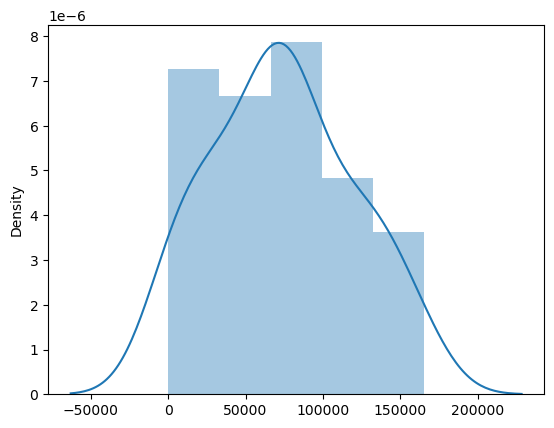

In [12]:
# univariate analysis
sns.distplot(x=df.RD_Spend,kde=True)

<Axes: ylabel='Density'>

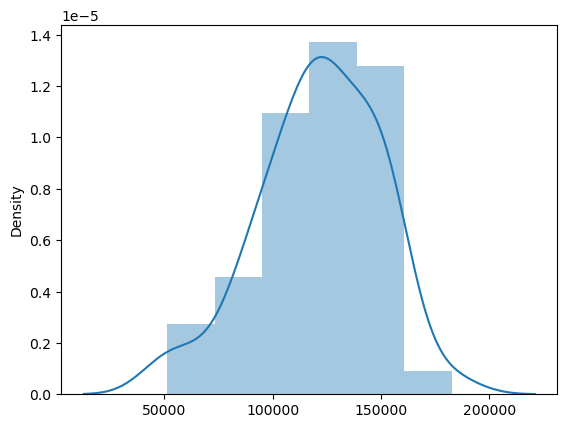

In [13]:
sns.distplot(x=df.Administration)

<Axes: ylabel='Density'>

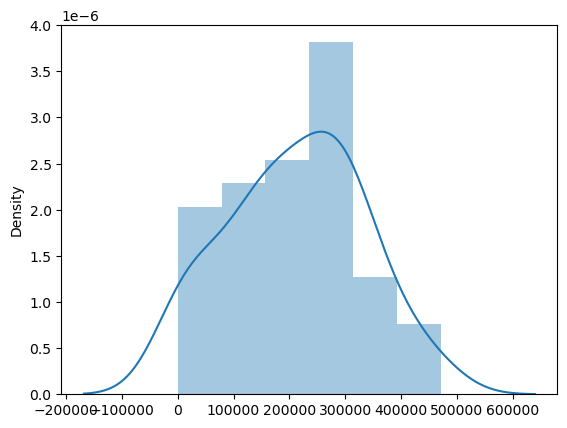

In [14]:
sns.distplot(x=df.Marketing_Spend)

<Axes: ylabel='Density'>

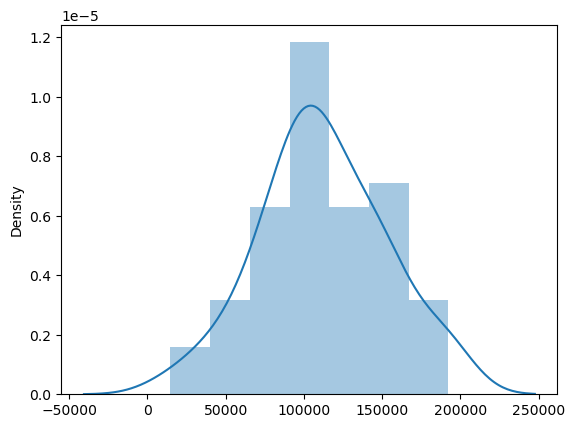

In [15]:
sns.distplot(x=df.Profit)

#insights

* Profit is representing normal distribution
* whereas RD_spend,Administration,Marketing are showing skewed distribution


<Axes: xlabel='RD_Spend', ylabel='Profit'>

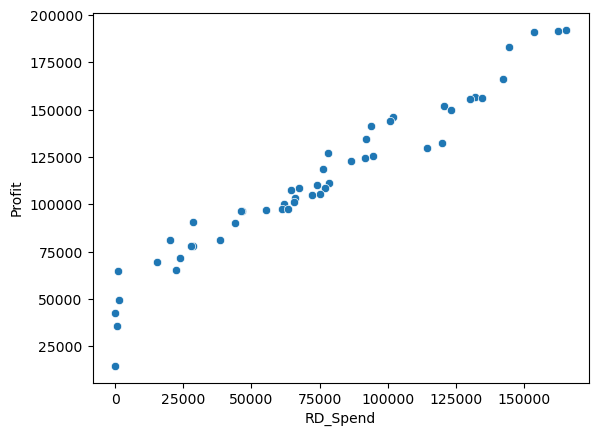

In [16]:
# Bivariate
sns.scatterplot(data=df,x='RD_Spend',y='Profit')

#insights

* strong positive relationship
* increase in amount spent on R&D increases profit
* there is high correlation between r&d and profit
* strong linear trend

<Axes: xlabel='Administration', ylabel='Profit'>

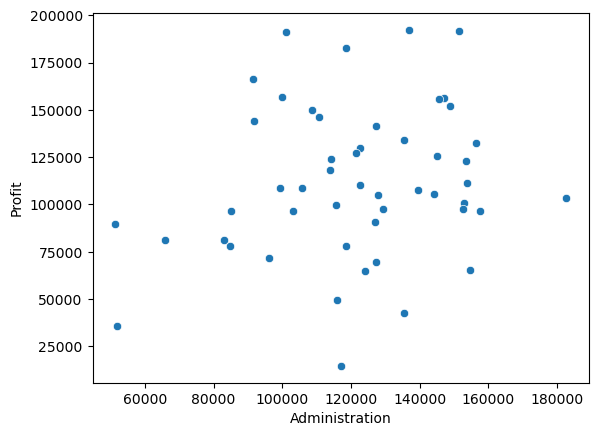

In [17]:
sns.scatterplot(data=df,x="Administration",y="Profit")

#insights

* weak or no correlation between administration and profit
* spending heavily on administration does not guarantee better profit

<Axes: xlabel='Marketing_Spend', ylabel='Profit'>

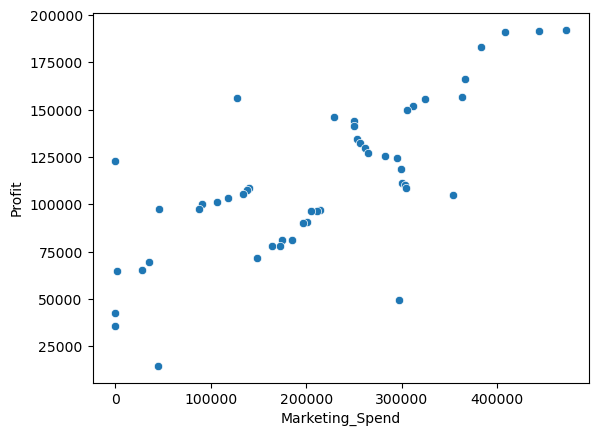

In [18]:
sns.scatterplot(data=df,x="Marketing_Spend",y="Profit")

#insights

* no strong relationship between marketing and profit
* increase in marketing does not indicate definte increase in profit

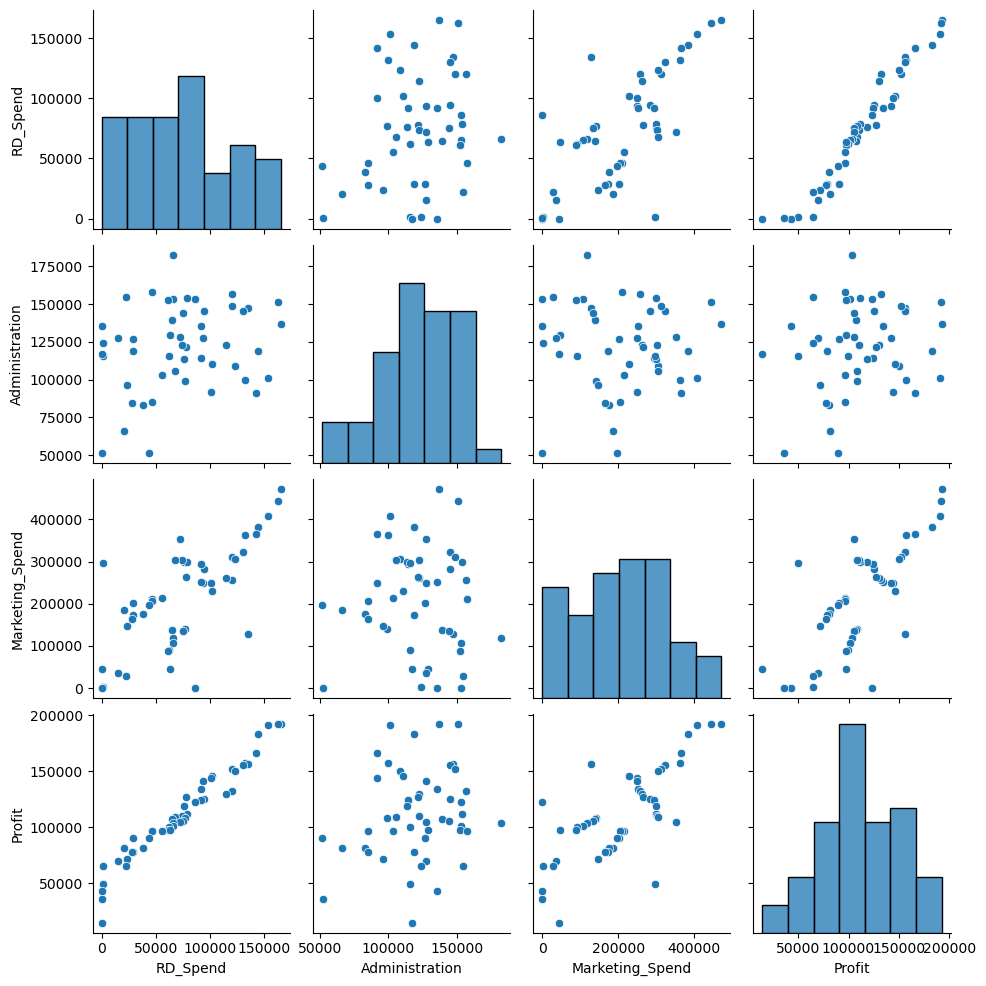

In [19]:
# multivariate
sns.pairplot(df)

#Data Cleaning

In [20]:
#missing value
df.isnull().sum()

RD_Spend           0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

In [21]:
#duplicates
df.duplicated().sum()

0

<Axes: xlabel='RD_Spend'>

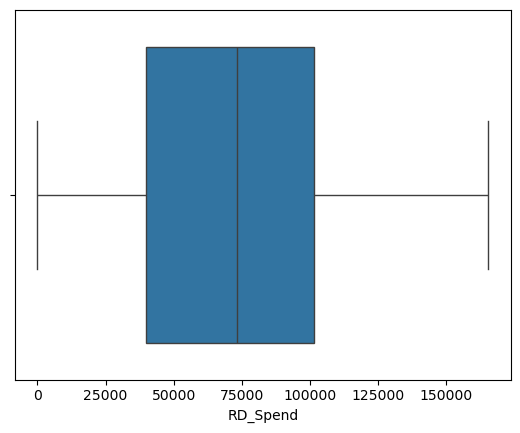

In [22]:
#outliers
sns.boxplot(x=df.RD_Spend)

<Axes: xlabel='Administration'>

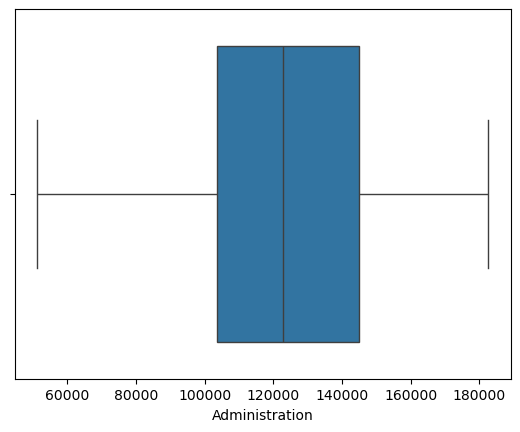

In [23]:
sns.boxplot(x=df.Administration)

<Axes: xlabel='Marketing_Spend'>

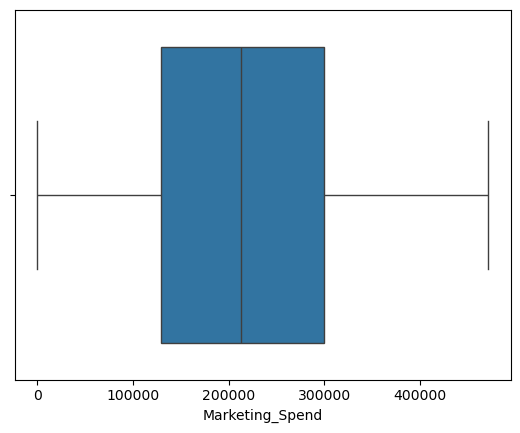

In [24]:
sns.boxplot(x=df.Marketing_Spend)

<Axes: xlabel='Profit'>

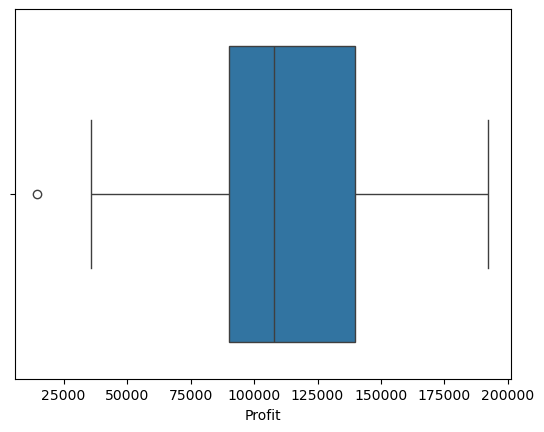

In [25]:
sns.boxplot(x=df.Profit)

In [26]:
Q1 = df['Profit'].quantile(0.25)
print("lower quantile",Q1)
Q3 = df['Profit'].quantile(0.75)
print("upper quantile",Q3)

lower quantile 90138.9025
upper quantile 139765.97749999998


In [27]:
IQR = Q3-Q1
IQR

49627.07499999998

In [28]:
lower_limit = Q1-1.5*IQR
print("lower limit is ",lower_limit)
upper_limit = Q3+1.5*IQR
print("upper limit is ",upper_limit)

lower limit is  15698.290000000023
upper limit is  214206.58999999997


In [29]:
df.loc[df['Profit']<lower_limit]

,RD_Spend,Administration,Marketing_Spend,State,Profit
49,0.0,116983.8,45173.06,California,14681.4


In [30]:
df.loc[df['Profit']>upper_limit]

,RD_Spend,Administration,Marketing_Spend,State,Profit


#len(df.loc[df['Profit']<lower_limit/len(df)])

In [31]:
df.loc[df['Profit']<lower_limit,"Profit"]=df['Profit'].median()

<Axes: xlabel='Profit'>

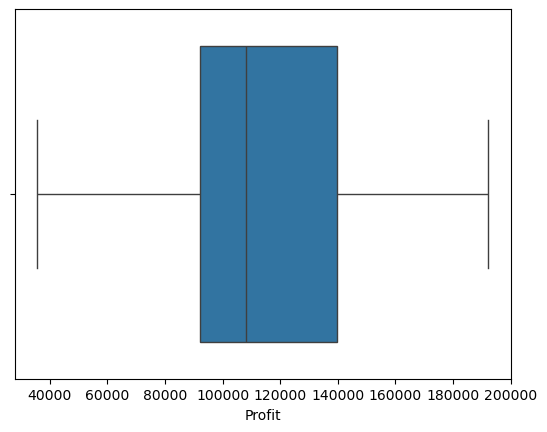

In [32]:
sns.boxplot(x=df.Profit)

<Axes: >

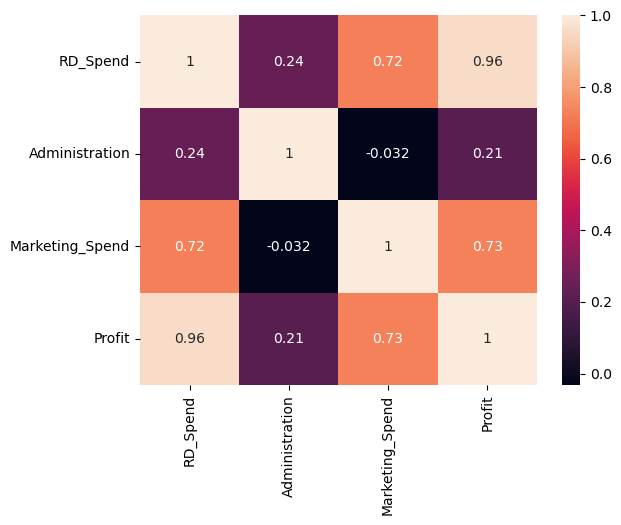

In [33]:
sns.heatmap(df.drop("State",axis=1).corr(),annot=True)  
#insights - R&D and Profit has very strong correlation so investing in R&D clearly drives profit
# Marketing and profit has good correlation of 0.73 and has strong influence on profit
# Administration has very correlation with profit so spending on administartion doesnt affect profit

<Axes: >

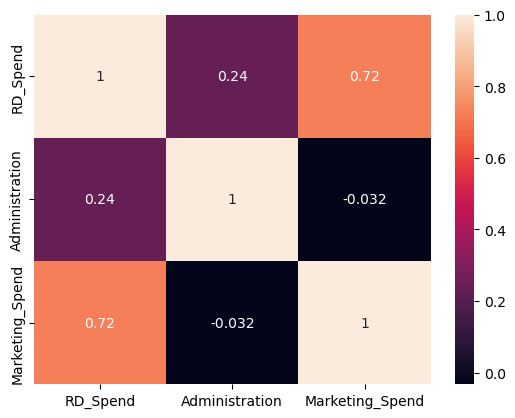

In [34]:
sns.heatmap(df.drop(["State","Profit"],axis=1).corr(),annot=True)
# R&D and Marketing correlate moderately with each other 0.72
# Administration and marketing has negative correlation -0.032
# Administration and R&D has less correlation of 0.24

In [35]:
x = df.drop(["Profit","State"],axis=1)
y = df["Profit"]

# Spliting Train Test Data

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=4)

In [38]:
x_train.shape

(35, 3)

In [39]:
x_test.shape

(15, 3)

In [40]:
y_train.shape

(35,)

In [41]:
y_test.shape

(15,)

# Model Building

In [42]:
from sklearn.linear_model import LinearRegression

# Initialize model

In [43]:
model = LinearRegression()

# train model with x_train & y_train

In [44]:
model.fit(x_train,y_train)

LinearRegression()

# Make prediction/test model

In [45]:
y_pred = model.predict(x_test)
y_pred

array([158855.57881208,  61750.26485862, 138102.06074947, 171068.99706191,
       130286.35079755, 101717.41608926, 157633.91998855, 105882.39104711,
        81961.25441272, 130077.55528635, 115919.46592143, 103597.92406523,
       102286.49710833, 146590.68030763, 118696.55290022])

In [46]:
y_test

6     156122.51
48     35673.41
11    144259.40
4     166187.94
12    141585.52
31     97483.56
7     155752.60
25    107404.34
41     77798.83
18    124266.90
22    110352.25
28    103282.38
33     96778.92
15    129917.04
16    126992.93
Name: Profit, dtype: float64

#slopes/coefficient 

In [47]:
model.coef_

array([ 0.76674877, -0.07307885,  0.01002598])

#intercept

In [48]:
model.intercept_

65115.97849011244

In [49]:
model.predict([[21892.92,81910.77,164270.7]])

array([77563.37726701])

In [50]:
model.predict([[23940.93,96489.63,137001.1]])

array([77794.87578148])

In [51]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [52]:
#mse
MSE=mean_squared_error(y_test,y_pred)
MSE

90667902.49447194

In [53]:
#mae
MAE=mean_absolute_error(y_test,y_pred)
MAE

7007.869894517202

In [54]:
#RMSE
rmse = np.sqrt(MSE)
rmse

9521.969465109198

In [55]:
r2_score(y_test,y_pred)

0.9168697376517042

In [56]:
#adjusted r2 score
adj_r2 = 1-(1-0.9168)*(15-1)/(15-3-1)
adj_r2

0.8941090909090909

In [57]:
!pip install pandoc

In [58]:
x= df[['RD_Spend','Administration','Marketing_Spend']]
y=df['Profit']

In [59]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(x,y)

LinearRegression()

In [60]:
df['Predicted_Profit'] = model.predict(x) 

In [61]:
df.to_csv('startups_with_predictions.csv',index=False)